## Домашнее задание: "Детекция объектов на изображении"

ФИО: Ергалиев Аслан Галымжанович

## Цель задания:
Научиться самостоятельно решать задачу детекции.
## Описание задания:
В рамках данного домашнего задания предлагается решить задачу детекции мячей и настроить полный пайплайн обучения модели.

Процесс выполнения задания следующий:

0. Выбор модели детекции для обучения:
    1. Выберите модель детекции для выполнения домашнего задания. Любую, кроме RetinaNet. Ее реализацию можно взять из открытых источников. Модель можно брать предобученную ( в этом случае в пункте 4. показать влияние предобучения на финальное качество).
    2. Полезные ссылки: [PyTorch Vision Models](https://pytorch.org/vision/stable/models.html) (блок Object Detection), [SOTA модели детекции](https://paperswithcode.com/sota/object-detection-on-coco), [Возможный пример кода](https://github.com/AlekseySpasenov/dl-course/blob/autumn_2023/lecture8/detection_example/pytorch_detection_workshop.ipynb)
    3. Вы можете использовать RetinaNet, которая была реализована на семинаре, но это приведет к снижению оценки на **–2.5 балла**, так как задания 1.1 и 2.1 уже были выполнены в рамках занятия.

1. Подготовка обучающего набора данных
    0. Для выполнения задания используйте датасет с изображениями мячей, который использовался на семинаре.
    1. Реализуйте корректный класс Dataset и Dataloader для выбранной модели (должен работать форвард вашей модели на том, что выходит из даталоадера) **0.5 балла**.
    2. Добавьте простые аугментации в датасет (аугментации, не затрагивающие изменение ground-truth bounding box) **0.5 балла**.
    3. Внедрите сложные аугментации (аугментации, затрагивающие изменение ground-truth bounding box. Например, аффинные преобразования: сдвиг, поворот и т.д.) **0.5 балла**.

    4. Полезные ссылки: https://pytorch.org/vision/stable/transforms.html , https://albumentations.ai

2. Реализация корректного train-loop и обучение модели:  
    1. Реализуйте эффективный train-loop для вашей модели и проведите обучение **2 балла**.
    2. Выполните несколько запусков обучения с различными параметрами, например: сравните влияние различных аугментаций, оцените влияние того была предобучена модель или нет, сравните результаты при изменении гиперпараметров итд (на ваш выбор) **0.5 балла**.

3. Валидация обученных моделей на тестовой выборке, вычисление метрики mAP
    1. Оцените качество моделей на тестовой части данных и рассчитайте метрику mAP **0.5 балл**
    2. Полезные ссылки: [mean_average_precision](https://github.com/bes-dev/mean_average_precision)

4. Выводы **0.5 балл**:
    1. Проанализируйте результаты обучения, визуально оцените качество работы модели.
    2. Прокомментируйте распространенные ошибки модели и предложите пути для улучшения финального решения.

In [3]:
# === Импорты ===
from pathlib import Path
import os, random, json
import numpy as np

import torch
import torchvision

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

# === Простой сид (без детерминизации) ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# === Девайс ===
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# === Пути (под твою структуру) ===
DATA_ROOT = Path("./balls_dataset")
IMAGES_DIR = DATA_ROOT / "seminar_objdet_retina_oi5_ball" / "oi5_ball"  # тут лежат картинки

TRAIN_ANN = DATA_ROOT / "seminar_objdet_retina_oi5_ball" / "oi5_ball_filename_to_bbox_train.json"
VAL_ANN   = DATA_ROOT / "seminar_objdet_retina_oi5_ball" / "oi5_ball_filename_to_bbox_val.json"
COCO_LABELS = DATA_ROOT / "seminar_objdet_retina_oi5_ball" / "coco_id_to_name.json"  # на случай, если понадобится

# Куда сохранять логи/веса/картинки
OUTPUT_ROOT = Path("./outputs/hw6")
WEIGHTS_DIR = OUTPUT_ROOT / "weights"
LOGS_DIR    = OUTPUT_ROOT / "logs"
FIGS_DIR    = OUTPUT_ROOT / "figs"
for p in [OUTPUT_ROOT, WEIGHTS_DIR, LOGS_DIR, FIGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Быстрые проверки
print("DATA_ROOT: ", DATA_ROOT.resolve())
print("IMAGES_DIR:", IMAGES_DIR.resolve(), "exists:", IMAGES_DIR.exists())
print("TRAIN_ANN:", TRAIN_ANN.resolve(), "exists:", TRAIN_ANN.exists())
print("VAL_ANN:  ", VAL_ANN.resolve(),   "exists:", VAL_ANN.exists())
print("COCO_LABELS:", COCO_LABELS.resolve(), "exists:", COCO_LABELS.exists())


Device: cuda
DATA_ROOT:  C:\Users\aslan\Desktop\TechnoPark\NeuroNetworks\HW6\balls_dataset
IMAGES_DIR: C:\Users\aslan\Desktop\TechnoPark\NeuroNetworks\HW6\balls_dataset\seminar_objdet_retina_oi5_ball\oi5_ball exists: True
TRAIN_ANN: C:\Users\aslan\Desktop\TechnoPark\NeuroNetworks\HW6\balls_dataset\seminar_objdet_retina_oi5_ball\oi5_ball_filename_to_bbox_train.json exists: True
VAL_ANN:   C:\Users\aslan\Desktop\TechnoPark\NeuroNetworks\HW6\balls_dataset\seminar_objdet_retina_oi5_ball\oi5_ball_filename_to_bbox_val.json exists: True
COCO_LABELS: C:\Users\aslan\Desktop\TechnoPark\NeuroNetworks\HW6\balls_dataset\seminar_objdet_retina_oi5_ball\coco_id_to_name.json exists: True


Загружено 2875 изображений из oi5_ball_filename_to_bbox_train.json
Загружено 226 изображений из oi5_ball_filename_to_bbox_val.json

=== Статистика TRAIN ===
Анализ первых 150 изображений:
  • Среднее число объектов: 2.24
  • Средняя ширина бокса:  0.145
  • Средняя высота бокса:  0.164
  • Средняя площадь бокса: 0.049
  • Макс площадь: 0.706, Мин площадь: 0.000

=== Статистика VAL ===
Анализ первых 150 изображений:
  • Среднее число объектов: 2.30
  • Средняя ширина бокса:  0.094
  • Средняя высота бокса:  0.116
  • Средняя площадь бокса: 0.030
  • Макс площадь: 0.999, Мин площадь: 0.000

Примеры изображений с bbox:


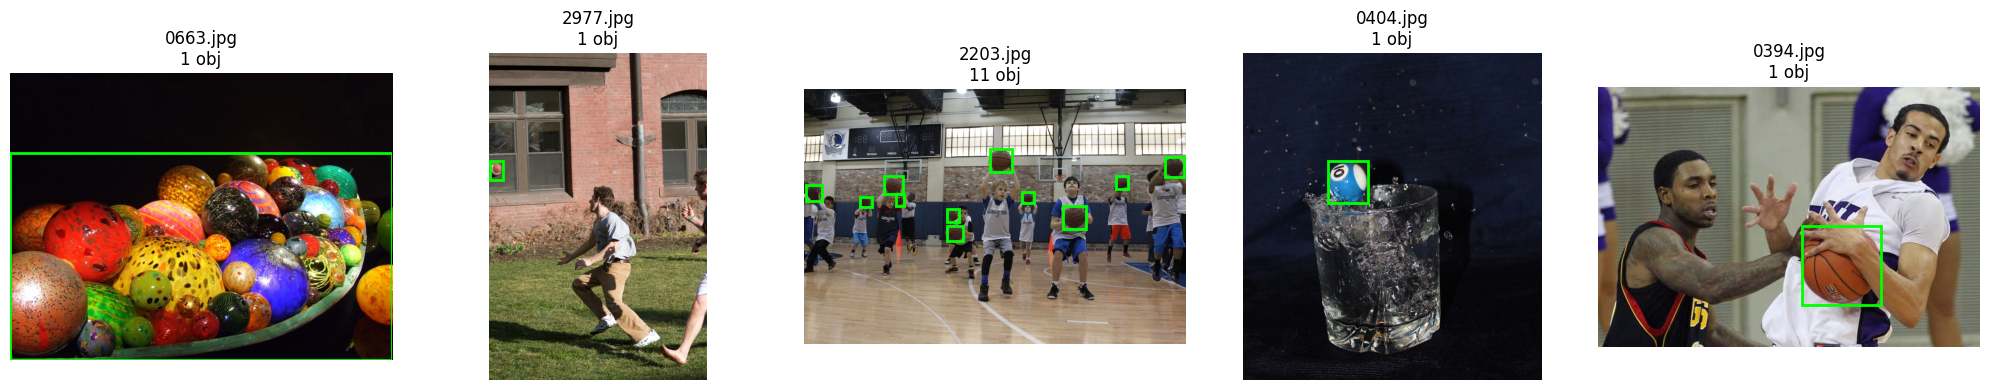

In [6]:
# === Анализ данных и визуализация ===

import json, random
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# Параметры для анализа
SAMPLES_TO_SHOW = 5
MAX_ANALYZE = 150  # ограничим для скорости

def load_annotations(json_path: Path):
    """Загружает json с аннотациями"""
    with open(json_path, 'r') as f:
        data = json.load(f)
    print(f"Загружено {len(data)} изображений из {json_path.name}")
    return data


def analyze_bboxes(data_dict):
    """Простая статистика по bounding boxes"""
    all_boxes = []
    obj_per_image = []

    for img_path, boxes in list(data_dict.items())[:MAX_ANALYZE]:
        obj_per_image.append(len(boxes))
        all_boxes.extend(boxes)

    if not all_boxes:
        print("⚠️ В аннотациях не найдено объектов.")
        return

    all_boxes = np.array(all_boxes)
    widths = all_boxes[:,1] - all_boxes[:,0]
    heights = all_boxes[:,3] - all_boxes[:,2]
    areas = widths * heights

    print(f"Анализ первых {min(MAX_ANALYZE, len(data_dict))} изображений:")
    print(f"  • Среднее число объектов: {np.mean(obj_per_image):.2f}")
    print(f"  • Средняя ширина бокса:  {np.mean(widths):.3f}")
    print(f"  • Средняя высота бокса:  {np.mean(heights):.3f}")
    print(f"  • Средняя площадь бокса: {np.mean(areas):.3f}")
    print(f"  • Макс площадь: {np.max(areas):.3f}, Мин площадь: {np.min(areas):.3f}")


def show_random_samples(data_dict, base_dir: Path, num_samples=5):
    """Показывает несколько случайных изображений с разметкой"""
    samples = random.sample(list(data_dict.items()), k=min(num_samples, len(data_dict)))

    fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 4))
    if len(samples) == 1:
        axes = [axes]

    for ax, (rel_path, boxes) in zip(axes, samples):
        img_path = base_dir / rel_path
        if not img_path.exists():
            ax.axis('off')
            continue

        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        w, h = img.size

        for b in boxes:
            x1, x2 = b[0]*w, b[1]*w
            y1, y2 = b[2]*h, b[3]*h
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)

        ax.set_title(f"{Path(rel_path).name}\n{len(boxes)} obj")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# === Запуск анализа ===

# Пути
train_json = TRAIN_ANN
val_json = VAL_ANN
base_images = IMAGES_DIR.parent  # каталог, где лежат все изображения

# Загружаем и анализируем
train_data = load_annotations(train_json)
val_data = load_annotations(val_json)

print("\n=== Статистика TRAIN ===")
analyze_bboxes(train_data)
print("\n=== Статистика VAL ===")
analyze_bboxes(val_data)

# Визуализация
print("\nПримеры изображений с bbox:")
show_random_samples(train_data, base_images, num_samples=SAMPLES_TO_SHOW)


In [31]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torch
import numpy as np
from PIL import Image

class BallDetectionDataset(Dataset):
    """
    Кастомный Dataset для задачи детекции мячей.
    Возвращает данные в формате, совместимом с torchvision моделями детекции.
    """
    def __init__(self, ann_file, images_root=None, augment=None, use_albu=False):
        with open(ann_file, "r") as f:
            self.items = json.load(f)
        self.images_root = Path(images_root) if images_root else None
        self.augment = augment
        self.use_albu = use_albu
        self.image_list = list(self.items.keys())

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        # путь к изображению
        rel_path = self.image_list[idx]
        img_path = (self.images_root / rel_path) if self.images_root else Path(rel_path)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # извлекаем боксы и метки
        boxes, labels = [], []
        for bb in self.items[rel_path]:
            x1, x2 = bb[0]*w, bb[1]*w
            y1, y2 = bb[2]*h, bb[3]*h
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        # --- Аугментации ---
        if self.augment:
            if self.use_albu:
                img_np = np.array(img)
                transformed = self.augment(image=img_np, bboxes=boxes.tolist(), labels=labels.tolist())

                img = transformed["image"]

                # приведение типа
                if img.dtype == torch.uint8:
                    img = img.float() / 255.0

                boxes = torch.tensor(transformed["bboxes"], dtype=torch.float32)
                labels = torch.tensor(transformed["labels"], dtype=torch.int64)

                # === Фильтр пустых боксов ===
                if len(boxes) == 0:
                    # Возьмём другое случайное изображение
                    new_idx = np.random.randint(0, len(self))
                    return self.__getitem__(new_idx)

                target = {"boxes": boxes, "labels": labels}
            else:
                img = self.augment(img)
        else:
            img = T.ToTensor()(img)

        return img, target


# collate_fn для DataLoader
def collate_fn(batch):
    images, targets = list(zip(*batch))
    return images, targets


In [28]:
# === Аугментации ===
# Без аугментаций
tfm_none = T.ToTensor()

# Лёгкие (только цвет/яркость, не трогают bbox)
tfm_light = T.Compose([
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1),
    T.RandomHorizontalFlip(0.4),
    T.ToTensor()
])

# Сложные (меняют bbox)
tfm_heavy = A.Compose([
    A.RandomResizedCrop(size=(320, 320), scale=(0.7, 1.0), ratio=(0.75, 1.33), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.2, rotate_limit=20, p=0.5, border_mode=cv2.BORDER_REFLECT_101),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))


C:\Users\aslan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
# Пример инициализации
train_ds = BallDetectionDataset(TRAIN_ANN, images_root=IMAGES_DIR.parent, augment=tfm_light)
val_ds   = BallDetectionDataset(VAL_ANN,   images_root=IMAGES_DIR.parent, augment=tfm_none)

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn)

# Проверим один батч
imgs, targets = next(iter(train_dl))
print(f"batch size: {len(imgs)}")
print("image tensor shape:", imgs[0].shape)
print("boxes example:", targets[0]['boxes'][:2])


batch size: 4
image tensor shape: torch.Size([3, 768, 1024])
boxes example: tensor([[ 38.4000, 216.3203, 566.4000, 733.4400],
        [374.4000, 128.6400, 623.3600, 377.6003]])


In [10]:
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_320_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from tqdm.auto import tqdm

In [11]:
# === Создание модели ===
def build_detector(num_classes=2, pretrained=True):
    weights = "DEFAULT" if pretrained else None
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# === Обучение ===
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, targets in tqdm(dataloader, desc="Training", leave=False):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
    return total_loss / len(dataloader)


# === Валидация ===
def evaluate_epoch(model, dataloader, device):
    model.train()  # нужно именно train() для вычисления loss
    total_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Validation", leave=False):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()
    model.eval()
    return total_loss / len(dataloader)

In [13]:
# === Подготовка ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используем:", device)

model = build_detector(num_classes=2, pretrained=True)
model.to(device)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.001, momentum=0.9, weight_decay=0.0005
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# === Обучение ===
num_epochs = 3
train_losses, val_losses = [], []

val_dl = DataLoader(val_ds, batch_size=4, shuffle=False, collate_fn=collate_fn)

for epoch in range(1, num_epochs + 1):
    print(f"\n=== Эпоха {epoch}/{num_epochs} ===")
    tr_loss = train_epoch(model, train_dl, optimizer, device)
    vl_loss = evaluate_epoch(model, val_dl, device)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)

    print(f"Train loss: {tr_loss:.4f} | Val loss: {vl_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# === Сохранение ===
save_path = WEIGHTS_DIR / "fasterrcnn_mobilenetv3_custom.pth"
torch.save(model.state_dict(), save_path)
print(f"\nМодель сохранена: {save_path.resolve()}")


Используем: cuda

=== Эпоха 1/3 ===


Training:   0%|          | 0/719 [00:00<?, ?it/s]

Validation:   0%|          | 0/57 [00:00<?, ?it/s]

Train loss: 0.2553 | Val loss: 0.2077 | LR: 0.001000

=== Эпоха 2/3 ===


Training:   0%|          | 0/719 [00:00<?, ?it/s]

Validation:   0%|          | 0/57 [00:00<?, ?it/s]

Train loss: 0.2194 | Val loss: 0.1885 | LR: 0.001000

=== Эпоха 3/3 ===


Training:   0%|          | 0/719 [00:00<?, ?it/s]

Validation:   0%|          | 0/57 [00:00<?, ?it/s]

Train loss: 0.2169 | Val loss: 0.1832 | LR: 0.000100

Модель сохранена: C:\Users\aslan\Desktop\TechnoPark\NeuroNetworks\HW6\outputs\hw6\weights\fasterrcnn_mobilenetv3_custom.pth


In [22]:
import torchvision.transforms.functional as F

def visualize_predictions(model, dataset, device, num_samples=5, score_thresh=0.4):
    model.eval()
    indices = torch.randperm(len(dataset))[:num_samples]

    for i in indices:
        img, target = dataset[i]
        img_tensor = img.to(device).unsqueeze(0)

        with torch.no_grad():
            preds = model(img_tensor)[0]

        boxes = preds['boxes'].cpu()
        scores = preds['scores'].cpu()

        keep = scores > score_thresh
        boxes = boxes[keep]
        scores = scores[keep]

        img_vis = (img * 255).byte()
        drawn = draw_bounding_boxes(img_vis, boxes, colors="lime", width=3)

        plt.figure(figsize=(6,6))
        plt.imshow(F.to_pil_image(drawn))
        plt.title(f"Detected {len(boxes)} objects, score>{score_thresh}")
        plt.axis("off")
        plt.show()




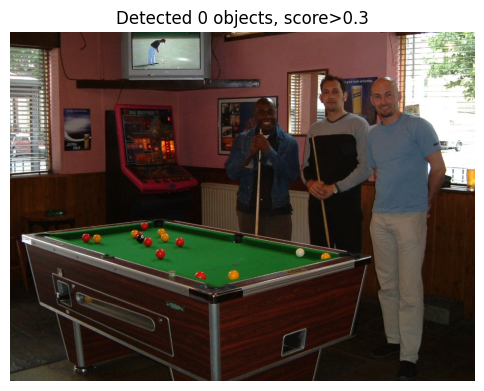

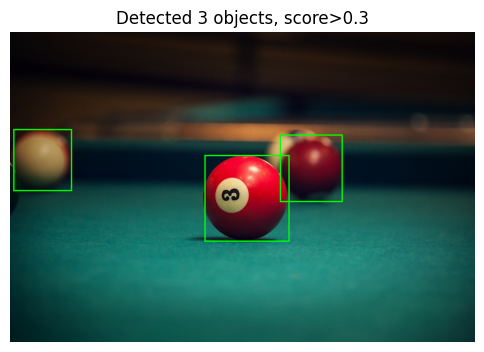

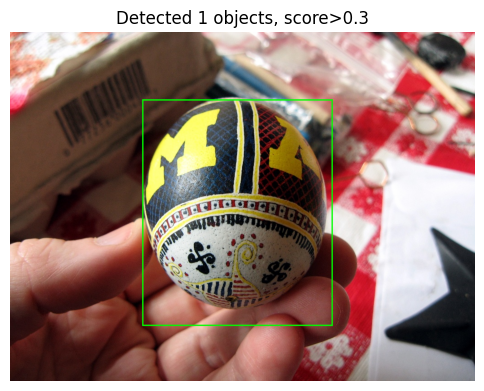

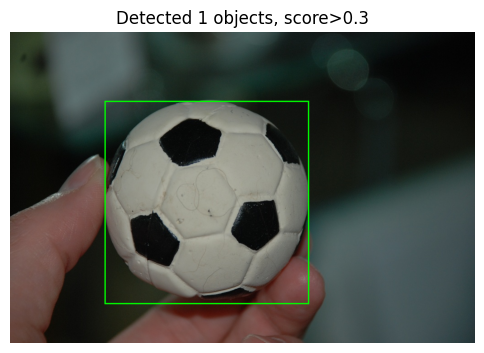

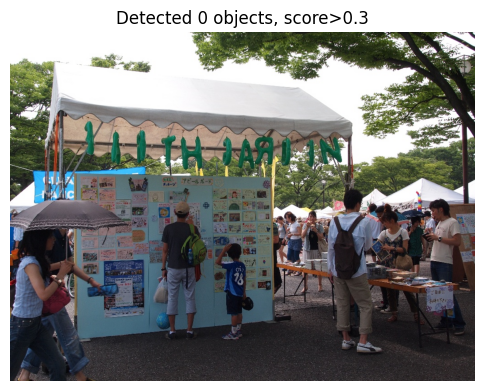

In [24]:
visualize_predictions(model, val_ds, device, num_samples=5, score_thresh=0.3)


In [32]:
# === Dataset с тяжёлыми аугментациями (Albumentations) ===
train_ds_heavy = BallDetectionDataset(
    TRAIN_ANN,
    images_root=IMAGES_DIR.parent,
    augment=tfm_heavy,
    use_albu=True  # важно, т.к. tfm_heavy сделан через Albumentations
)

val_ds_heavy = BallDetectionDataset(
    VAL_ANN,
    images_root=IMAGES_DIR.parent,
    augment=tfm_none
)

train_dl_heavy = DataLoader(train_ds_heavy, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_dl_heavy   = DataLoader(val_ds_heavy, batch_size=4, shuffle=False, collate_fn=collate_fn)


In [33]:
# === Обучение на тяжёлых аугментациях ===
num_epochs_heavy = 5  # можно 5–10, если время позволяет

train_losses_h, val_losses_h = [], []

print("\n🔥 Запуск обучения с тяжёлыми аугментациями...")
for epoch in range(1, num_epochs_heavy + 1):
    print(f"\n=== Эпоха {epoch}/{num_epochs_heavy} (Heavy Augmentations) ===")
    tr_loss = train_epoch(model, train_dl_heavy, optimizer, device)
    vl_loss = evaluate_epoch(model, val_dl_heavy, device)
    scheduler.step()

    train_losses_h.append(tr_loss)
    val_losses_h.append(vl_loss)

    print(f"Train loss: {tr_loss:.4f} | Val loss: {vl_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")



🔥 Запуск обучения с тяжёлыми аугментациями...

=== Эпоха 1/5 (Heavy Augmentations) ===


Training:   0%|          | 0/719 [00:00<?, ?it/s]

Validation:   0%|          | 0/57 [00:00<?, ?it/s]

Train loss: 0.2755 | Val loss: 0.2039 | LR: 0.000100

=== Эпоха 2/5 (Heavy Augmentations) ===


Training:   0%|          | 0/719 [00:00<?, ?it/s]

...

Training:   0%|          | 0/719 [00:00<?, ?it/s]

Validation:   0%|          | 0/57 [00:00<?, ?it/s]

Train loss: 0.2960 | Val loss: 0.2351 | LR: 0.000010

=== Эпоха 4/5 (Heavy Augmentations) ===


Training:   0%|          | 0/719 [00:00<?, ?it/s]

AssertionError: All bounding boxes should have positive height and width. Found invalid box [139.83192443847656, 320.0, 223.1931610107422, 320.0] for target at index 3.

### Оставьте обратную связь по занятию №6
Это поможет улучшить курс и сделать следующие занятия ещё лучше!
Форма обратной связи: https://forms.gle/hTfRQaGBrqic7LyP6
